In [102]:
import Kea
from Kea.utils import plotting, data_reader
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

from Kea.api.sim_data import SimulationData, SimulationType
from Kea.api.spectrum import Spectrum, SpectrumMethod

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

from scipy import fft

L = 2.*np.pi
D = 3
d = D - 1
phys_dims = [L for _ in range(D)]

In [2]:
data = SimulationData(SimulationType.H5_SEAN, '/home/m/Documents/science_codes/Data/cmhd3d/', ['rho'], '04', phys_dims=phys_dims)
_ = data.dephase_data(['rho'])

_ = data.project('rho', axis=2)
_ = data.dephase_data('x3proj_rho')

Reading file: z3-mhd3-04-uno-Xsp-rho.h5
Loaded rho
Created rho_dephase
Created x3proj_rho
Created x3proj_rho_dephase


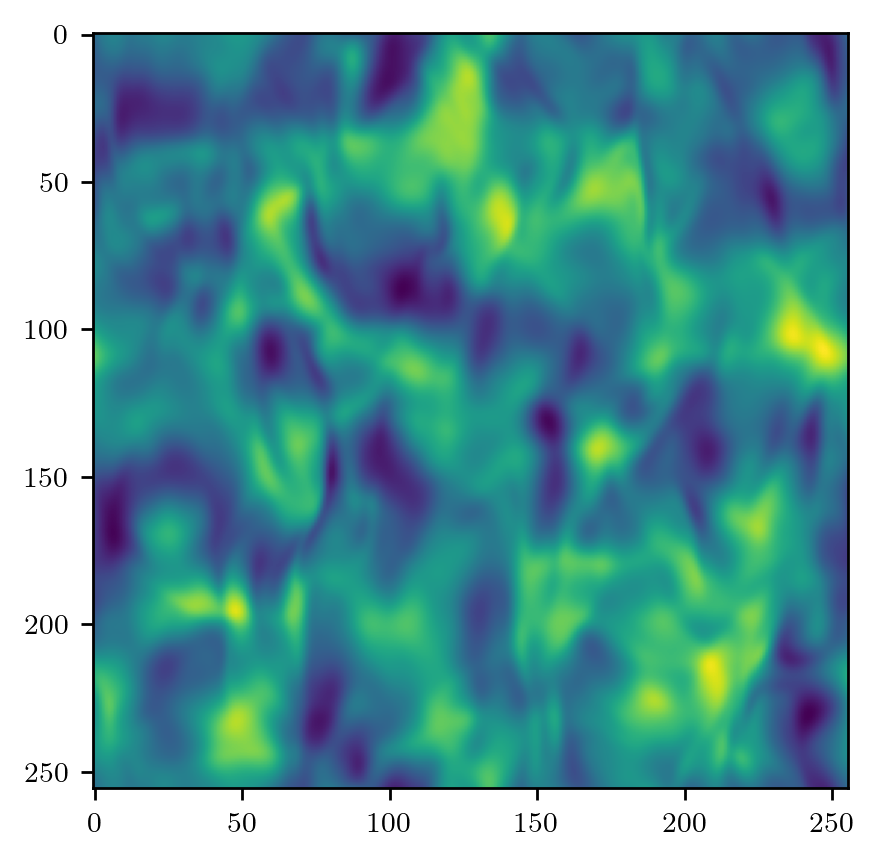

In [128]:
plt.imshow(data.rho[:,:,128])

In [3]:
rho_spec = data.spectrum('rho')
_, _ = rho_spec.integrate()
rhod_spec = data.spectrum('rho_dephase')
_, _ = rhod_spec.integrate()
proj_rho_spec = data.spectrum('x3proj_rho')
_, _ = proj_rho_spec.integrate()
proj_rhod_spec = data.spectrum('x3proj_rho_dephase')
_, _ = proj_rhod_spec.integrate()

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


In [4]:
a_rho_spec = data.spectrum('rho', 'arevalo')
a_rhod_spec = data.spectrum('rho_dephase', 'arevalo')
a_proj_rho_spec = data.spectrum('x3proj_rho', 'arevalo')
a_proj_rhod_spec = data.spectrum('x3proj_rho_dephase', 'arevalo')

/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/arevalo_spectra.py:263: RuntimeWarning: divide by zero encountered in true_divide
  lags = np.sqrt(2. * D + 6.) / (2. * k)
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/arevalo_spectra.py:145: RuntimeWarning: invalid value encountered in double_scalars
  result = m_comp * var / gauss_var


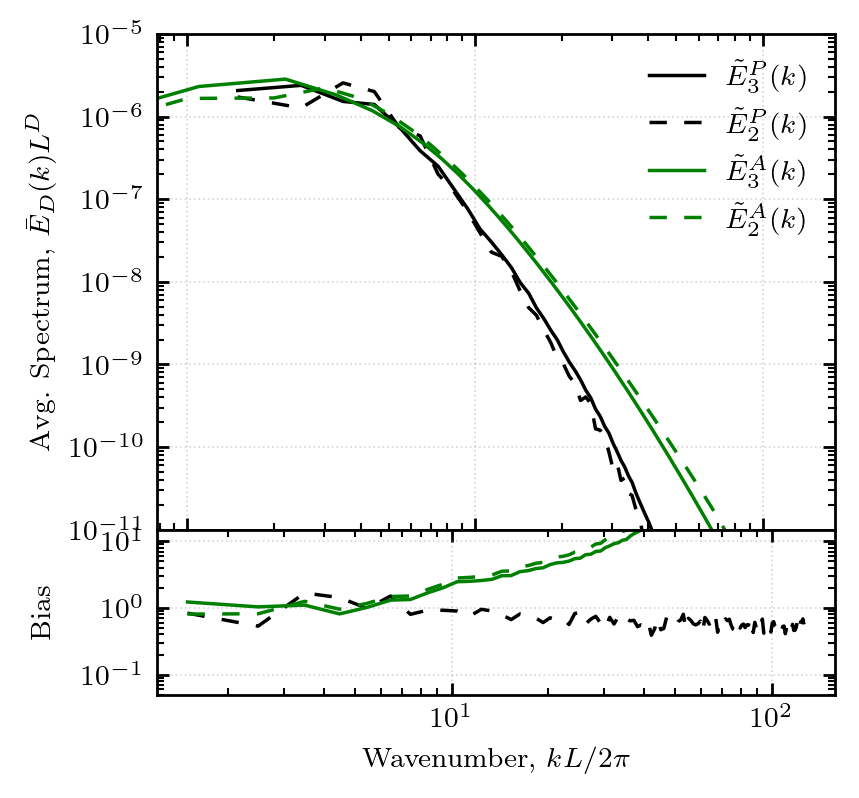

In [41]:
## 3D and Projected
fig = plt.figure(1, dpi=250, figsize=(3.5, 3.5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax = [ax0, ax1]

ax0.loglog(rho_spec.modal_k, rho_spec.modal_fek/L**D, linewidth=1., color='black')
ax0.loglog(proj_rho_spec.modal_k, proj_rho_spec.modal_fek/L**d, linewidth=1., color='black', linestyle=(0,(5,5)))
ax0.loglog(a_rho_spec.modal_k, a_rho_spec.modal_fek/L**D, linewidth=1., color='green')
ax0.loglog(a_proj_rho_spec.modal_k, a_proj_rho_spec.modal_fek/L**d, linewidth=1., color='green', linestyle=(0,(5,5)))

kk, bb = proj_rho_spec.bias(rho_spec)
ax1.plot(kk, bb*L, linewidth=1., color='black', linestyle=(0,(5,5)))
kk, bb = a_rho_spec.bias(rho_spec)
ax1.plot(kk, bb, linewidth=1., color='green')
kk, bb = a_proj_rho_spec.bias(rho_spec)
ax1.plot(kk, bb*L, linewidth=1., color='green', linestyle=(0,(5,5)))

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')

    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel('Avg. Spectrum, $\\bar{E}_{D}(k) L^D$')
ax[1].set_ylabel('Bias')

ax[1].set_xlabel(r'Wavenumber, $kL/2\pi$')

ax[0].set_ylim((1e-11, 1e-5))

ax[1].set_ylim((0.5e-1, 1.5e1))

ax[0].plot([], [], linewidth=1., color='black', label=r'$\tilde{E}_3^P(k)$')
ax[0].plot([], [], linewidth=1., color='black', linestyle=(0,(5,5)), label=r'$\tilde{E}_2^P(k)$')
ax[0].plot([], [], linewidth=1., color='green', label=r'$\tilde{E}^A_3(k)$')
ax[0].plot([], [], linewidth=1., color='green', linestyle=(0,(5,5)), label=r'$\tilde{E}_2^A(k)$')

ax[0].legend(frameon=False, fancybox=False, shadow=False)

fig.subplots_adjust(wspace=0.01)
fig.align_ylabels()


In [94]:
## Fit to spectra, generate fBm field with same parameters
def exp_powerlaw(xx, a1, a2, a3, a4, bb, b1, b2, delta):
    pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
    # Set where it is not defined to 0
    pl[~np.isfinite(pl)] = 0.
    # Outside the axis to be 0
    minn = np.where(xx == np.nanmin(xx))
    idx = [m for m in minn]
    idx[0] = slice(0,np.max(xx.shape))
    idx = tuple(idx)
    maxx = np.max(xx[idx])
    pl[xx > maxx] = 0.
    pl = pl/pl[1]
    return pl

from scipy.optimize import curve_fit

fit = curve_fit(exp_powerlaw, rho_spec.modal_k, rho_spec.modal_fek)
print(fit[0])

[3.83739146e+00 7.30281784e-01 1.29533096e+01 8.59870729e-01
 1.08863355e+07 1.85644574e+00 7.63230284e-02 1.00000686e+00]


/tmp/ipykernel_81088/3323555969.py:3: RuntimeWarning: overflow encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
/tmp/ipykernel_81088/3323555969.py:3: RuntimeWarning: invalid value encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
/tmp/ipykernel_81088/3323555969.py:13: RuntimeWarning: invalid value encountered in true_divide
  pl = pl/pl[1]


(1e-15, 1e-05)

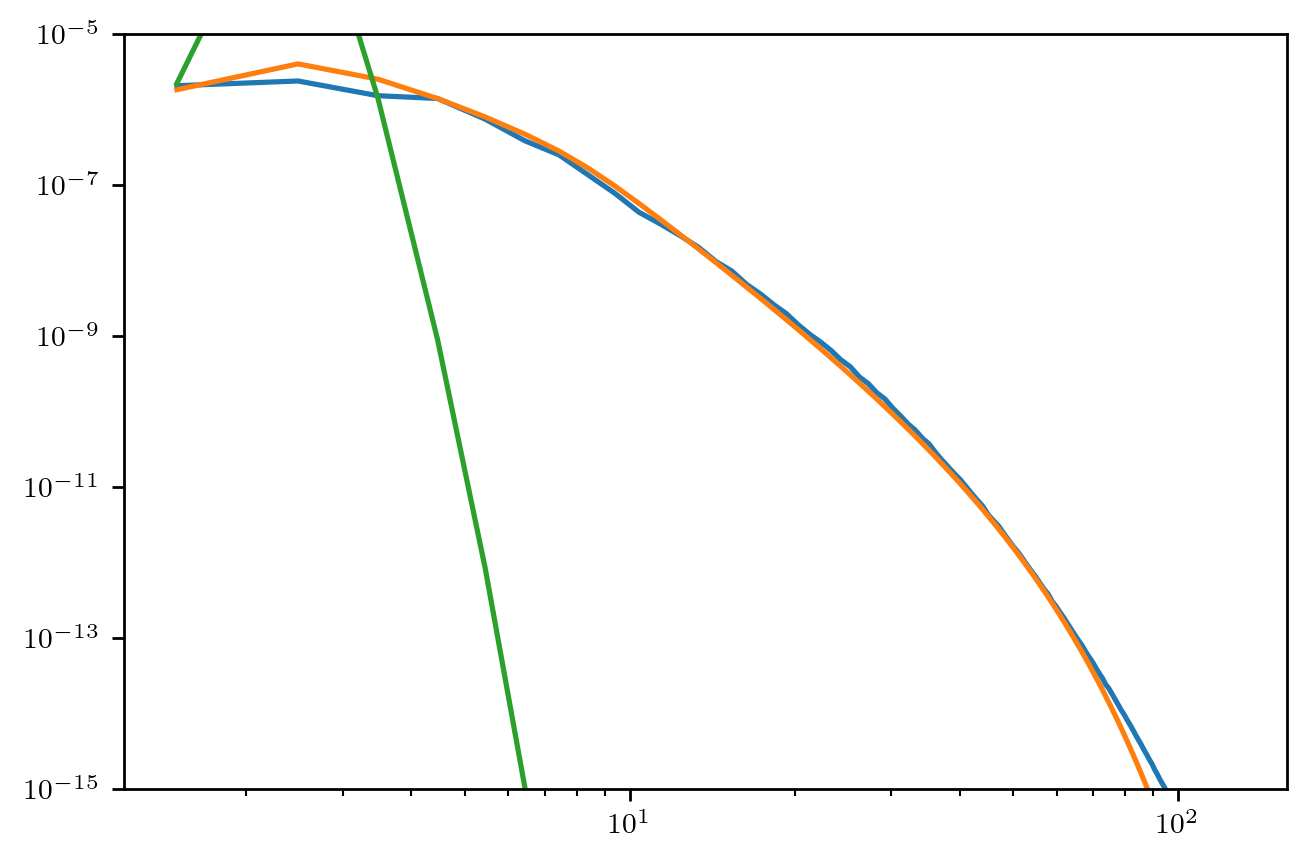

In [98]:
plt.loglog(rho_spec.modal_k, rho_spec.modal_fek/L**D)
plt.loglog(rho_spec.modal_k, exp_powerlaw(rho_spec.modal_k, 3.5, 5.5, 2., 2., 8., 3., 35., 0.1)/L**D/1e3)
plt.loglog(rho_spec.modal_k, exp_powerlaw(rho_spec.modal_k, *fit[0])/L**D)
plt.ylim((1e-15, 1e-5))

In [113]:
# 3.5, 5.5, 2., 2., 8., 3., 35., 0.1) / L**D / 1e3

def exp_powerlaw(xx, alphas):
    a1, a2, a3, a4 = 3.5, 5.5, 2., 2.
    bb, b1, b2 = 8., 3., 35.
    delta = 0.1
    pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
    # Set where it is not defined to 0
    pl[~np.isfinite(pl)] = 0.
    # Outside the axis to be 0
    minn = np.where(xx == np.nanmin(xx))
    idx = [m for m in minn]
    idx[0] = slice(0,np.max(xx.shape))
    idx = tuple(idx)
    maxx = np.max(xx[idx])
    pl[xx > maxx] = 0.
    #pl = pl/pl[1]
    return pl

fbm_field = fbm.create_fbm([256, 256, 256], [L, L, L], (500.,), gfunc=exp_powerlaw)


/tmp/ipykernel_81088/2203245553.py:7: RuntimeWarning: divide by zero encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
/tmp/ipykernel_81088/2203245553.py:7: RuntimeWarning: divide by zero encountered in true_divide
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)
/tmp/ipykernel_81088/2203245553.py:7: RuntimeWarning: invalid value encountered in multiply
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta) * np.exp(-(b1/xx)**a3) * np.exp(-(xx/b2)**a4)


In [116]:
fbm_spec = Spectrum.compute_spectrum(fbm_field, phys_dims=[L,L,L], method=SpectrumMethod.PERIODOGRAM, varname='rho')
fbm_spec.integrate()
a_fbm_spec = Spectrum.compute_spectrum(fbm_field, phys_dims=[L,L,L], method=SpectrumMethod.AREVALO, varname='rho')

proj_field = np.nanmean(fbm_field, axis=2)

proj_fbm_spec = Spectrum.compute_spectrum(proj_field, phys_dims=[L,L], method=SpectrumMethod.PERIODOGRAM, varname='x3proj_rho')
proj_fbm_spec.integrate()
a_proj_fbm_spec = Spectrum.compute_spectrum(proj_field, phys_dims=[L,L], method=SpectrumMethod.AREVALO, varname='x3proj_rho')

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/arevalo_spectra.py:263: RuntimeWarning: divide by zero encountered in true_divide
  lags = np.sqrt(2. * D + 6.) / (2. * k)
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/arevalo_spectra.py:145: RuntimeWarning: invalid value encountered in double_scalars
  result = m_comp * var / gauss_var
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/arevalo_spectra.py:263: RuntimeWarning: divide by zero encountered in true_divide
  lags = np.sqrt(2. * D + 6.) / (2. * k)
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/arevalo_spectra.py:145: RuntimeWarning: invalid value encounte

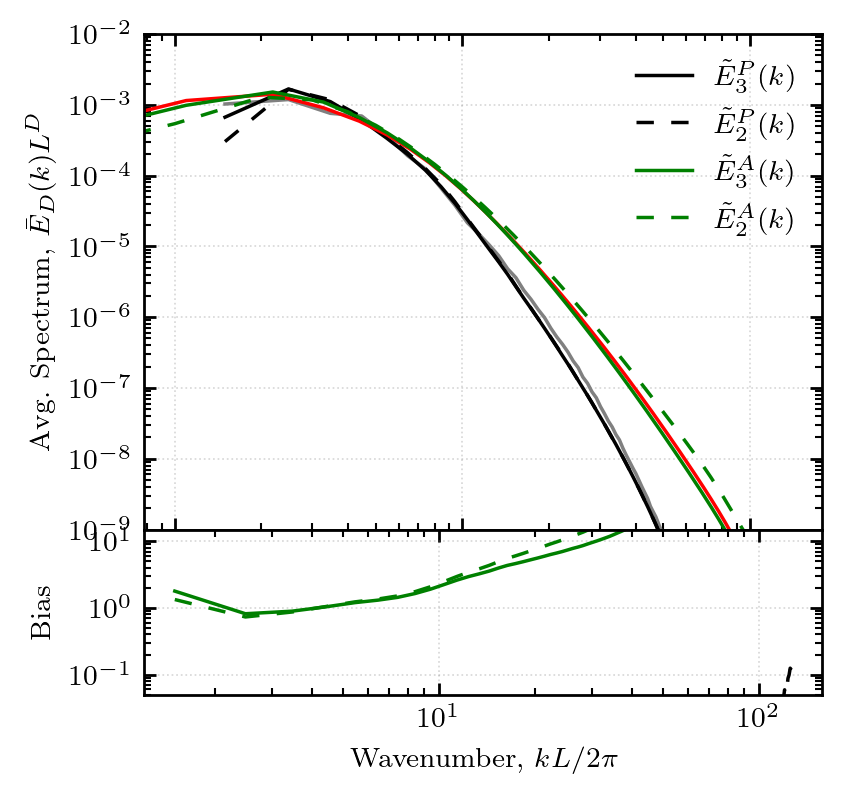

In [125]:
## COMPARE TO FBM FIELD WITH SIMILAR POWERLAW
## 3D and Projected
fig = plt.figure(1, dpi=250, figsize=(3.5, 3.5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax = [ax0, ax1]

ax0.loglog(rho_spec.modal_k, rho_spec.modal_fek*2, linewidth=1., color='gray')

ax0.loglog(fbm_spec.modal_k, fbm_spec.modal_fek/L**D, linewidth=1., color='black')
ax0.loglog(proj_fbm_spec.modal_k, proj_fbm_spec.modal_fek/L**d, linewidth=1., color='black', linestyle=(0,(5,5)))

ax0.loglog(a_rho_spec.modal_k, a_rho_spec.modal_fek*2, linewidth=1., color='red')

ax0.loglog(a_fbm_spec.modal_k, a_fbm_spec.modal_fek/L**D, linewidth=1., color='green')
ax0.loglog(a_proj_fbm_spec.modal_k, a_proj_fbm_spec.modal_fek/L**d, linewidth=1., color='green', linestyle=(0,(5,5)))

kk, bb = proj_rho_spec.bias(fbm_spec)
ax1.plot(kk, bb*L, linewidth=1., color='black', linestyle=(0,(5,5)))
kk, bb = a_fbm_spec.bias(fbm_spec)
ax1.plot(kk, bb, linewidth=1., color='green')
kk, bb = a_proj_fbm_spec.bias(fbm_spec)
ax1.plot(kk, bb*L, linewidth=1., color='green', linestyle=(0,(5,5)))

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')

    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel('Avg. Spectrum, $\\bar{E}_{D}(k) L^D$')
ax[1].set_ylabel('Bias')

ax[1].set_xlabel(r'Wavenumber, $kL/2\pi$')

ax[0].set_ylim((1e-9, 1e-2))

ax[1].set_ylim((0.5e-1, 1.5e1))

ax[0].plot([], [], linewidth=1., color='black', label=r'$\tilde{E}_3^P(k)$')
ax[0].plot([], [], linewidth=1., color='black', linestyle=(0,(5,5)), label=r'$\tilde{E}_2^P(k)$')
ax[0].plot([], [], linewidth=1., color='green', label=r'$\tilde{E}^A_3(k)$')
ax[0].plot([], [], linewidth=1., color='green', linestyle=(0,(5,5)), label=r'$\tilde{E}_2^A(k)$')

ax[0].legend(frameon=False, fancybox=False, shadow=False)

fig.subplots_adjust(wspace=0.01)
fig.align_ylabels()

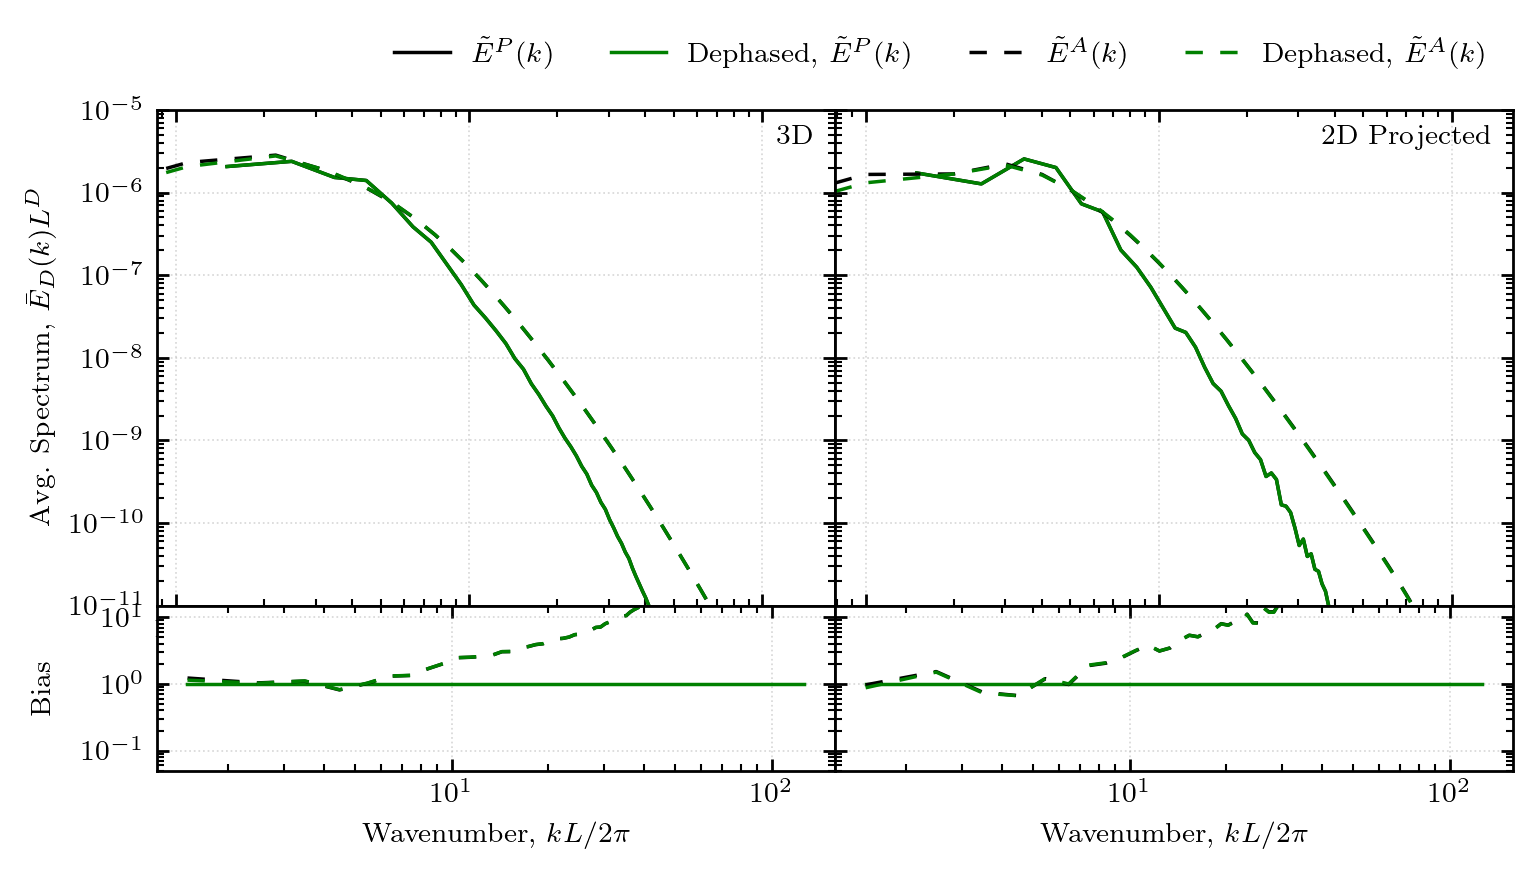

In [37]:
## Compare dephased
## 3D and Projected
fig = plt.figure(1, dpi=250, figsize=(7., 3.5))
gs = mpl.gridspec.GridSpec(2, 2, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
ax = [ax0, ax1, ax2, ax3]

## 3D
ax0.loglog(rho_spec.modal_k, rho_spec.modal_fek/L**D, linewidth=1., color='black')
ax0.loglog(rhod_spec.modal_k, rhod_spec.modal_fek/L**D, linewidth=1., color='green')

ax0.loglog(a_rho_spec.modal_k, a_rho_spec.modal_fek/L**D, linestyle=(0,(5,5)), linewidth=1., color='black')
ax0.loglog(a_rhod_spec.modal_k, a_rhod_spec.modal_fek/L**D, linestyle=(0,(5,5)), linewidth=1., color='green')

kk, bb = rhod_spec.bias(rho_spec)
ax2.plot(kk, bb, linewidth=1., color='green')
kk, bb = a_rho_spec.bias(rho_spec)
ax2.plot(kk, bb, linewidth=1., color='black', linestyle=(0,(5,5)))
kk, bb = a_rhod_spec.bias(rho_spec)
ax2.plot(kk, bb, linewidth=1, color='green', linestyle=(0,(5,5)))

## 2D
d = D - 1

ax1.loglog(proj_rho_spec.modal_k, proj_rho_spec.modal_fek/L**d, linewidth=1., color='black')
ax1.loglog(proj_rhod_spec.modal_k, proj_rhod_spec.modal_fek/L**d, linewidth=1., color='green')
ax1.loglog(a_proj_rho_spec.modal_k, a_proj_rho_spec.modal_fek/L**d, linestyle=(0,(5,5)), linewidth=1., color='black')
ax1.loglog(a_proj_rhod_spec.modal_k, a_proj_rhod_spec.modal_fek/L**d, linestyle=(0,(5,5)), linewidth=1., color='green')

kk, bb = proj_rhod_spec.bias(proj_rho_spec)
ax3.plot(kk, bb, linewidth=1., color='green')
kk, bb = a_proj_rho_spec.bias(proj_rho_spec)
ax3.plot(kk, bb, linewidth=1., color='black', linestyle=(0,(5,5)))
kk, bb = a_proj_rhod_spec.bias(proj_rho_spec)
ax3.plot(kk, bb, linewidth=1, color='green', linestyle=(0,(5,5)))

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')

    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel('Avg. Spectrum, $\\bar{E}_{D}(k) L^D$')
ax[2].set_ylabel('Bias')

ax[1].set_yticklabels([])
ax[3].set_yticklabels([])

ax[2].set_xlabel(r'Wavenumber, $kL/2\pi$')
ax[3].set_xlabel(r'Wavenumber, $kL/2\pi$')
ax[0].set_ylim((1e-11, 1e-5))
ax[1].set_ylim((1e-11, 1e-5))

ax[2].set_ylim((0.5e-1, 1.5e1))
ax[3].set_ylim((0.5e-1, 1.5e1))

ax[0].plot([], [], linewidth=1., color='black', label=r'$\tilde{E}^P(k)$')
ax[0].plot([], [], linewidth=1., color='green', label=r'Dephased, $\tilde{E}^P(k)$')
ax[0].plot([], [], linewidth=1., color='black', linestyle=(0,(5,5)), label=r'$\tilde{E}^A(k)$')
ax[0].plot([], [], linewidth=1., color='green', linestyle=(0,(5,5)), label=r'Dephased, $\tilde{E}^A(k)$')

ax[0].legend(frameon=False, fancybox=False, bbox_to_anchor=(2.0, 1.2), shadow=False, ncol=4)

ax[0].text(0.97, 0.97, r'3D', transform=ax[0].transAxes, ha='right', va='top')
ax[1].text(0.97, 0.97, r'2D Projected', transform=ax[1].transAxes, ha='right', va='top')

fig.subplots_adjust(wspace=0.01)
fig.align_ylabels()
